# Notebook 08 — Three-way comparison: variant A vs H (HMM-as-feature) vs B (VIX)

**Experimental design.**

| Variant | Inputs | Architecture | Checkpoints | Trained where |
|---|---|---|---|---|
| **A** (current) | stationary + sentiment (7 feats) | baseline + regime-split ensemble | `lstm_{baseline,calm,volatile}.pt` (default names) | **nb 04 + nb 05** |
| **H** (HMM-as-feature) | variant A features + `p_volatile` (8 feats) | **single** baseline LSTM (no ensemble) | `lstm_baseline_H.pt` | **this notebook** |
| **B** (VIX-family) | variant A features + VIX family (10 feats) | baseline + regime-split ensemble | `lstm_{baseline,calm,volatile}_B.pt` | **this notebook** |

**Upstream dependencies.** This notebook assumes nb 01 → nb 05 have been
executed first (they produce the feature parquets, HMM regime probabilities,
and variant A's LSTM checkpoints). `src/ensemble.py` with no `--variant-suffix`
should also have been run so that `data/processed/test_predictions.parquet`
contains variant A's ensemble output.

**What this notebook trains:** 4 LSTMs (1 for variant H, 3 for variant B).
Variant A's 3 LSTMs are trained in nb 04 / nb 05 — reused here.

**The question variant H asks.** Our existing regime-split architecture
*gates* LSTM predictions using the HMM's soft probabilities (p_calm,
p_volatile). Variant H instead feeds `p_volatile` as a normal input feature
to a single LSTM — testing whether the regime signal needs the ensemble
architecture at all, or whether a single LSTM that *sees* the regime signal
can match / beat the gated ensemble. Complements the linear Ridge-stacking
result in `src/gate_stacking.py` (which showed *linear* combination can't do
better than baseline); variant H is the *nonlinear* version of that test.

**Reproducibility.** Re-executing this notebook from scratch retrains the 4
new LSTMs and regenerates every variant-H / variant-B output. To also
retrain variant A's LSTMs, run nb 04 and nb 05 first.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch
from scipy import stats as sp_stats

import config
from src.ensemble import get_aligned_predictions
from src.utils import regression_metrics

plt.rcParams["figure.dpi"] = 110
print("ROOT:", ROOT)
print("Variant A features (7):", config.LSTM_VARIANT_A_FEATURES)
print("Variant H features (8):", config.LSTM_VARIANT_H_FEATURES)
print("Variant B features (10):", config.LSTM_VARIANT_B_FEATURES)


ROOT: /Users/zaidt/Desktop/cpsc440/StockVolatilitySight
Variant A features (7): ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'relative_volume_21d', 'bullish', 'bearish']
Variant H features (8): ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'relative_volume_21d', 'bullish', 'bearish', 'p_volatile']
Variant B features (10): ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'relative_volume_21d', 'bullish', 'bearish', 'vix', 'vix_log_change', 'vix3m_minus_vix']


## 1. Data-prerequisites check

Confirm the saved parquets contain every column all three variants need, and
confirm variant A's checkpoints + ensemble predictions exist (they come from
nb 04 → nb 05 → `src/ensemble.py` upstream).


In [2]:
train_df = pd.read_parquet(config.DATA_PROCESSED / "train.parquet")
val_df   = pd.read_parquet(config.DATA_PROCESSED / "val.parquet")
test_df  = pd.read_parquet(config.DATA_PROCESSED / "test.parquet")

all_needed = (
    set(config.LSTM_VARIANT_A_FEATURES)
    | set(config.LSTM_VARIANT_H_FEATURES)
    | set(config.LSTM_VARIANT_B_FEATURES)
    | {config.LSTM_TARGET}
)
missing = {
    name: sorted(all_needed - set(df.columns))
    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]
}
assert not any(missing.values()), f"Missing columns: {missing}"

summary = pd.DataFrame({
    col: [df[col].isna().sum() for df in (train_df, val_df, test_df)]
    for col in sorted(all_needed)
}, index=["train", "val", "test"])
summary.loc["n_rows"] = [len(train_df), len(val_df), len(test_df)]

# Check variant A upstream artefacts
variant_A_pred = config.DATA_PROCESSED / "test_predictions.parquet"
variant_A_ckpts = [config.MODELS_DIR / f"lstm_{m}.pt" for m in ("baseline", "calm", "volatile")]
assert variant_A_pred.exists(), f"Variant A predictions missing: {variant_A_pred} — run nb06/ensemble.py first"
for p in variant_A_ckpts:
    assert p.exists(), f"Variant A checkpoint missing: {p} — run nb04/nb05 first"
print(f"Variant A artefacts present ({len(variant_A_ckpts)} checkpoints + predictions).")
summary


ValueError: cannot set a row with mismatched columns

## 2. Training — variant H (1 LSTM) and variant B (3 LSTMs)

Variant A's three LSTMs come from nb 04 / nb 05 (not retrained here).

Same seed (`LSTM_RANDOM_STATE = 42`) and Optuna budget as the nb 04 / nb 05
trainings — the only difference across variants is the input feature set.


In [3]:
feat_H = " ".join(config.LSTM_VARIANT_H_FEATURES)
feat_B = " ".join(config.LSTM_VARIANT_B_FEATURES)

LOG_DIR = ROOT / "logs"
LOG_DIR.mkdir(exist_ok=True)

print("feat_H:", feat_H)
print("feat_B:", feat_B)


feat_H: log_return abs_return oc_return intraday_range relative_volume_21d bullish bearish p_volatile
feat_B: log_return abs_return oc_return intraday_range relative_volume_21d bullish bearish vix vix_log_change vix3m_minus_vix


In [4]:
# --- (1/4) Variant H: single baseline LSTM with p_volatile as an input feature ---
!cd {ROOT} && python -m src.train_LSTM_baseline \
    --features {feat_H} \
    --output-prefix lstm_baseline_H \
    > {LOG_DIR}/seven_H_baseline.log 2>&1
!tail -30 {LOG_DIR}/seven_H_baseline.log


{
  "best_params": {
    "hidden_size": 128,
    "n_layers": 1,
    "dropout": 0.3069738046984882,
    "lr": 0.0037962460764876544,
    "batch_size": 64,
    "seq_len": 21
  },
  "best_val_mse_raw": 3.710628516273573e-05,
  "retrained_val_mse_raw": 3.710628516273573e-05,
  "test_metrics": {
    "MSE": 1.6186615539481863e-05,
    "RMSE": 0.0040232595056295395,
    "MAE": 0.0025652276817709208,
    "n_test_windows": 1455
  },
  "features": [
    "log_return",
    "abs_return",
    "oc_return",
    "intraday_range",
    "relative_volume_21d",
    "bullish",
    "bearish",
    "p_volatile"
  ],
  "target": "realized_vol_21d",
  "n_trials": 20
}


In [5]:
# --- (2/4) Variant B baseline LSTM ---
!cd {ROOT} && python -m src.train_LSTM_baseline \
    --features {feat_B} \
    --output-prefix lstm_baseline_B \
    > {LOG_DIR}/seven_B_baseline.log 2>&1
!tail -30 {LOG_DIR}/seven_B_baseline.log


    "hidden_size": 64,
    "n_layers": 3,
    "dropout": 0.24064424648301128,
    "lr": 0.009818226878189128,
    "batch_size": 32,
    "seq_len": 21
  },
  "best_val_mse_raw": 3.6531266232486814e-05,
  "retrained_val_mse_raw": 3.6531266232486814e-05,
  "test_metrics": {
    "MSE": 1.5515859558945522e-05,
    "RMSE": 0.003939017653465271,
    "MAE": 0.0025761458091437817,
    "n_test_windows": 1461
  },
  "features": [
    "log_return",
    "abs_return",
    "oc_return",
    "intraday_range",
    "relative_volume_21d",
    "bullish",
    "bearish",
    "vix",
    "vix_log_change",
    "vix3m_minus_vix"
  ],
  "target": "realized_vol_21d",
  "n_trials": 20
}


In [6]:
# --- (3-4/4) Variant B regime LSTMs (calm + volatile) ---
!cd {ROOT} && python -m src.train_LSTM_regime \
    --features {feat_B} \
    --regime both \
    --output-suffix _B \
    > {LOG_DIR}/seven_B_regime.log 2>&1
!tail -50 {LOG_DIR}/seven_B_regime.log


      "oc_return",
      "intraday_range",
      "relative_volume_21d",
      "bullish",
      "bearish",
      "vix",
      "vix_log_change",
      "vix3m_minus_vix"
    ],
    "target": "realized_vol_21d",
    "n_trials": 20,
    "n_train_windows": 1887,
    "n_val_windows": 1043
  },
  "volatile": {
    "regime": "volatile",
    "best_params": {
      "hidden_size": 128,
      "n_layers": 3,
      "dropout": 0.37088369802778925,
      "lr": 0.0029741800657664855,
      "batch_size": 32,
      "seq_len": 42
    },
    "best_val_mse_raw": 1.1715013897628523e-05,
    "retrained_val_mse": 1.1715013897628523e-05,
    "test_metrics": {
      "MSE": 0.4524296522140503,
      "RMSE": 0.6726289391517639,
      "MAE": 0.17962777614593506,
      "n_test_windows": 1440
    },
    "features": [
      "log_return",
      "abs_return",
      "oc_return",
      "intraday_range",
      "relative_volume_21d",
      "bullish",
      "bearish",
      "vix",
      "vix_log_change",
      "vix3m_minus_vi

## 3. Produce test-set predictions for variants B and H

- **Variant B** goes through `src/ensemble.py` with `--variant-suffix _B`,
  loading the three `_B` LSTMs and the HMM regime probabilities. Writes
  `data/processed/test_predictions_B.parquet`.
- **Variant H** is a single LSTM — no ensemble step. Predictions come
  directly from `get_aligned_predictions()` and are saved to
  `data/processed/test_predictions_H.parquet` for symmetry.

Variant A's `test_predictions.parquet` was already written by
`src/ensemble.py` (no suffix) upstream.


In [7]:
!cd {ROOT} && python src/ensemble.py --variant-suffix _B > {LOG_DIR}/seven_B_ensemble.log 2>&1
!tail -30 {LOG_DIR}/seven_B_ensemble.log


PHASE 4: ENSEMBLE EVALUATION (TEST SET)
Test period: 2020-06-30 to 2026-03-24
Test size:   1440 trading days
--------------------------------------------------
Model: BASELINE
  MSE:  0.000015
  RMSE: 0.0039
  MAE:  0.0025
  MAPE: 25.21%
--------------------------------------------------
Model: CALM
  MSE:  0.000015
  RMSE: 0.0039
  MAE:  0.0025
  MAPE: 27.05%
--------------------------------------------------
Model: VOLATILE
  MSE:  0.452430
  RMSE: 0.6726
  MAE:  0.1796
  MAPE: 2576.99%
--------------------------------------------------
Model: ENSEMBLE
  MSE:  0.000014
  RMSE: 0.0037
  MAE:  0.0025
  MAPE: 26.80%
--------------------------------------------------


In [8]:
# Variant H: single-model predictions, saved to test_predictions_H.parquet
device = torch.device("cpu")
pred_H = get_aligned_predictions("baseline", test_df, device, suffix="_H")
pred_H.name = "baseline"

df_H = pred_H.to_frame()
df_H["target"] = test_df[config.LSTM_TARGET]
df_H = df_H.dropna()
out_path_H = config.DATA_PROCESSED / "test_predictions_H.parquet"
df_H.to_parquet(out_path_H)
print(f"Saved variant-H predictions → {out_path_H}  (rows={len(df_H)})")
df_H.describe().round(5)


Saved variant-H predictions → /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/data/processed/test_predictions_H.parquet  (rows=1455)


,baseline,target
count,1455.00000,1455.00000
mean,0.00863,0.00955
std,0.00283,0.00444
min,0.00566,0.00332
25%,0.00685,0.00652
50%,0.00772,0.00841
75%,0.00945,0.01146
max,0.03555,0.03221


## 4. Test-set metrics — 4 comparable strategies

1. **Naive** — `rolling_std_21` at time t (persistence-shifted identity by construction).
2. **Variant A** — 3-LSTM regime-split ensemble (post-merge: stationary + sentiment).
3. **Variant H** — single baseline LSTM with `p_volatile` as an input feature.
4. **Variant B** — 3-LSTM regime-split ensemble + VIX family.

Aligned on the common test-date index so the comparison is row-for-row.


In [9]:
pred_A = pd.read_parquet(config.DATA_PROCESSED / "test_predictions.parquet")
pred_B = pd.read_parquet(config.DATA_PROCESSED / "test_predictions_B.parquet")
pred_H = pd.read_parquet(config.DATA_PROCESSED / "test_predictions_H.parquet")

common = pred_A.index.intersection(pred_B.index).intersection(pred_H.index)
pred_A = pred_A.loc[common]
pred_B = pred_B.loc[common]
pred_H = pred_H.loc[common]
y_true = pred_A["target"].values

# Naive baseline = rolling_std_21 at time t (reactive)
naive = test_df["rolling_std_21"].reindex(common).values

metrics_rows = []
for label, pred in [
    ("naive",        naive),
    ("variant A (ensemble)", pred_A["ensemble"].values),
    ("variant H (HMM-feat)", pred_H["baseline"].values),
    ("variant B (ensemble)", pred_B["ensemble"].values),
]:
    m = regression_metrics(y_true, pred)
    metrics_rows.append({"predictor": label, **{k: float(v) for k, v in m.items()}})
headline = pd.DataFrame(metrics_rows).set_index("predictor")
headline


,MSE,RMSE,MAE,MAPE
predictor,,,,
naive,0.000022,0.004695,0.003133,34.617481
variant A (ensemble),0.000014,0.003770,0.002480,24.639501
variant H (HMM-feat),0.000016,0.003973,0.002517,24.943261
variant B (ensemble),0.000014,0.003735,0.002477,26.870617


### Per-component breakdown (variants A and B)

How much of each variant's performance comes from the baseline LSTM alone vs.
the ensemble weighting?


In [10]:
breakdown_rows = []
for variant, df in [("A", pred_A), ("B", pred_B)]:
    for model in ["baseline", "calm", "volatile"]:
        m = regression_metrics(y_true, df[model].values)
        breakdown_rows.append(
            {"variant": variant, "model": model, **{k: float(v) for k, v in m.items()}}
        )
pd.DataFrame(breakdown_rows).set_index(["variant", "model"])


MSE      RMSE       MAE         MAPE
variant model                                              
A       baseline  0.000017  0.004147  0.002720    26.347485
        calm      0.000014  0.003798  0.002474    24.536621
        volatile  0.000089  0.009411  0.008765   121.945248
B       baseline  0.000015  0.003916  0.002547    25.258262
        calm      0.000015  0.003890  0.002514    27.124695
        volatile  0.454323  0.674035  0.180352  2587.531877

## 5. Diebold-Mariano pairwise tests

Six pairwise comparisons across (naive, A, H, B), both MSE and MAE loss.
Positive DM ⇒ first-listed predictor has higher loss ⇒ second-listed wins.
h = 21 with Bartlett HAC + HLN small-sample correction.


In [11]:
def diebold_mariano(y_true, y_pred_a, y_pred_b, h=21, loss="mse"):
    y_true = np.asarray(y_true, float)
    y_a, y_b = np.asarray(y_pred_a, float), np.asarray(y_pred_b, float)
    e_a = (y_a - y_true) ** 2 if loss == "mse" else np.abs(y_a - y_true)
    e_b = (y_b - y_true) ** 2 if loss == "mse" else np.abs(y_b - y_true)
    d = e_a - e_b
    n = len(d); d_bar = float(d.mean())
    max_lag = max(h - 1, 0)
    gamma0 = float(np.var(d, ddof=0))
    S = gamma0
    for k in range(1, max_lag + 1):
        w = 1.0 - k / (max_lag + 1)
        gamma_k = float(np.mean((d[k:] - d_bar) * (d[:-k] - d_bar)))
        S += 2.0 * w * gamma_k
    if S <= 0:
        S = gamma0
    dm_raw = d_bar / np.sqrt(S / n)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    dm_stat = float(dm_raw * hln)
    p = float(2.0 * (1.0 - sp_stats.t.cdf(np.abs(dm_stat), df=n - 1)))
    return {"dm_stat": dm_stat, "p_value": p, "n": n}


preds = {
    "naive":       naive,
    "A.ensemble":  pred_A["ensemble"].values,
    "H.baseline":  pred_H["baseline"].values,
    "B.ensemble":  pred_B["ensemble"].values,
}
labels = list(preds.keys())
rows = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        a, b = labels[i], labels[j]
        for loss in ["mse", "mae"]:
            r = diebold_mariano(y_true, preds[a], preds[b], loss=loss)
            sig = "***" if r["p_value"] < 0.01 else "**" if r["p_value"] < 0.05 else "*" if r["p_value"] < 0.10 else ""
            winner = (b if r["dm_stat"] > 0 else a) if r["p_value"] < 0.05 else "tie"
            rows.append({
                "A":  a,  "B": b,  "loss": loss.upper(),
                "DM": round(r["dm_stat"], 3),
                "p":  round(r["p_value"], 4),
                "sig": sig, "winner": winner,
            })
pd.DataFrame(rows)


,A,B,loss,DM,p,sig,winner
0,naive,A.ensemble,MSE,1.676,0.0939,*,tie
1,naive,A.ensemble,MAE,3.066,0.0022,***,A.ensemble
2,naive,H.baseline,MSE,1.506,0.1323,,tie
3,naive,H.baseline,MAE,2.750,0.0060,***,H.baseline
4,naive,B.ensemble,MSE,1.730,0.0838,*,tie
5,naive,B.ensemble,MAE,3.078,0.0021,***,B.ensemble
6,A.ensemble,H.baseline,MSE,-0.929,0.3530,,tie
7,A.ensemble,H.baseline,MAE,-0.316,0.7519,,tie
8,A.ensemble,B.ensemble,MSE,0.271,0.7863,,tie
9,A.ensemble,B.ensemble,MAE,0.027,0.9785,,tie


## 6. F1 diagnostic — cross-correlation peak lag

For each predictor compute `corr(pred_t, target_{t+ℓ})` over ℓ ∈ [−30, 30].
F1 says variant A peaks at ℓ ≈ −17 (a persistence predictor shifted ~17
days). Does variant H or B pull the peak toward ℓ = 0?


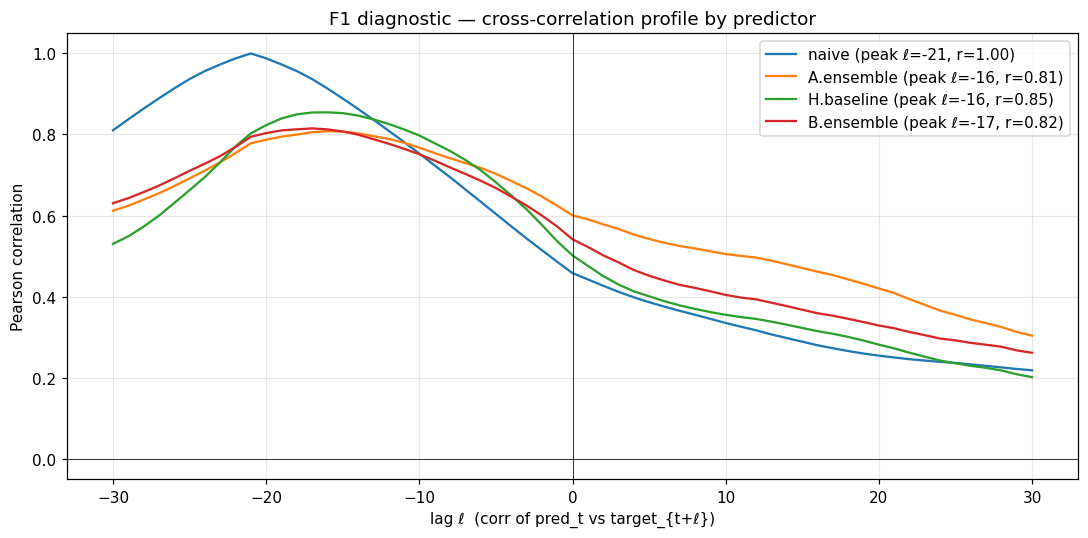

,peak_lag,peak_corr,lag0_corr
predictor,,,
naive,-21,1.000,0.458
A.ensemble,-16,0.808,0.600
H.baseline,-16,0.855,0.502
B.ensemble,-17,0.815,0.541


In [12]:
def cross_correlation_lag_profile(preds, target, max_lag=30):
    preds = np.asarray(preds, float); target = np.asarray(target, float)
    lags = np.arange(-max_lag, max_lag + 1)
    corrs = []
    for L in lags:
        if L < 0:   p, t = preds[-L:], (target[:L] if L else target)
        elif L > 0: p, t = preds[:-L], target[L:]
        else:       p, t = preds, target
        corrs.append(np.corrcoef(p, t)[0, 1] if len(p) > 2 else np.nan)
    return lags, np.array(corrs)


fig, ax = plt.subplots(figsize=(10, 5))
peaks = []
for label, pred in preds.items():
    lags, corrs = cross_correlation_lag_profile(pred, y_true)
    peak_lag = int(lags[np.nanargmax(corrs)])
    peak_corr = float(np.nanmax(corrs))
    zero_lag_corr = float(corrs[lags == 0][0])
    peaks.append({"predictor": label, "peak_lag": peak_lag,
                  "peak_corr": round(peak_corr, 3),
                  "lag0_corr": round(zero_lag_corr, 3)})
    ax.plot(lags, corrs, label=f"{label} (peak ℓ={peak_lag}, r={peak_corr:.2f})")
ax.axvline(0, color="k", lw=0.5); ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("lag ℓ  (corr of pred_t vs target_{t+ℓ})")
ax.set_ylabel("Pearson correlation")
ax.set_title("F1 diagnostic — cross-correlation profile by predictor")
ax.legend(loc="best"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

pd.DataFrame(peaks).set_index("predictor")


## 7. F2 diagnostic — prediction-std per LSTM

Prediction std / range for each regime LSTM (calm, volatile) across variants
A and B. If variant B's volatile LSTM is still near-constant (std ≈ 1e-4),
F2 holds. Variant H has no volatile LSTM — it absorbs the regime signal
through `p_volatile`.


In [13]:
f2_rows = []
for variant, df in [("A", pred_A), ("B", pred_B)]:
    for model in ["baseline", "calm", "volatile"]:
        p = df[model].dropna().values
        f2_rows.append({"variant": variant, "model": model,
                        "mean":  round(float(p.mean()),  6),
                        "std":   round(float(p.std()),   6),
                        "min":   round(float(p.min()),   6),
                        "max":   round(float(p.max()),   6),
                        "range": round(float(p.max() - p.min()), 6)})
pH = pred_H["baseline"].dropna().values
f2_rows.append({"variant": "H", "model": "baseline",
                "mean":  round(float(pH.mean()),  6),
                "std":   round(float(pH.std()),   6),
                "min":   round(float(pH.min()),   6),
                "max":   round(float(pH.max()),   6),
                "range": round(float(pH.max() - pH.min()), 6)})
pd.DataFrame(f2_rows).set_index(["variant", "model"])


mean       std       min       max     range
variant model                                                     
A       baseline  0.008219  0.003175  0.005720  0.026815  0.021095
        calm      0.008790  0.003937  0.006078  0.031116  0.025038
        volatile  0.017773  0.000193  0.017694  0.019146  0.001452
B       baseline  0.008533  0.002860  0.006185  0.035273  0.029089
        calm      0.009393  0.003107  0.005904  0.036240  0.030336
        volatile  0.189364  0.648990  0.017742  2.712347  2.694605
H       baseline  0.008577  0.002787  0.005657  0.035551  0.029895

## 8. Summary (fill in after execution)

Template — update once the tables/plots above render with actual numbers:

- **Aggregate metrics ranking** (lowest MSE wins): which of A / H / B is best?
- **Variant H (HMM-as-feature)**: does it match or beat variant A's ensemble? If yes → "the regime signal is better exploited via a feature than via gating," a clean structural claim. If no → the gating architecture does add value beyond what a feature can capture.
- **Variant B (+VIX) vs. A**: does the VIX augmentation still help with the now-richer (sentiment-augmented) baseline, or does sentiment already absorb most of the forward-looking signal?
- **F1 (shift lag)**: do any of the variants pull the peak cross-correlation lag toward ℓ = 0? If none does, the persistence-shift floor is a structural property of the data/horizon, not the feature set.
- **F2 (volatile degeneracy)**: do variant B's calm / volatile LSTMs look different post-sentiment-merge? Is variant H's single-LSTM architecture immune to the F2 failure mode?

The three-way comparison (A vs H vs B) is the cleanest single claim the
paper's experiments section can make — whether the HMM signal is better
exploited through gating (architecture) or through features (input), and
whether forward-looking options-market data escapes the F1 floor.
